#### Step 1: Load Dataset with Textual Data Preview
Load the CSV dataset and inspect its head, tail, info, and summary statistics.

In [1]:
# Import Data Preprocessing Libraries
import pandas
import numpy

pandas.set_option("display.max_rows", None) 
pandas.set_option("display.max_columns", None)

# Load the CSV dataset "major-tech-stock-2019-2024.csv"
dataset = pandas.read_csv("./datasets/major-tech-stock-2019-2024.csv", header=0, index_col=0)

# Inspect the dataset
print("--- Dataset Head ---")
print(dataset.head(), "\n")

print("--- Dataset Tail ---")
print(dataset.tail(), "\n")

print("--- Dataset Info ---")
print(dataset.info(), "\n")

print("--- Dataset Description (Describe) ---")
print(dataset.describe(), "\n")

--- Dataset Head ---
                 Open       High        Low      Close  Adj Close     Volume  \
Date                                                                           
2019-01-02  38.722500  39.712502  38.557499  39.480000  37.793785  148158800   
2019-01-03  35.994999  36.430000  35.500000  35.547501  34.029243  365248800   
2019-01-04  36.132500  37.137501  35.950001  37.064999  35.481926  234428400   
2019-01-07  37.174999  37.207500  36.474998  36.982498  35.402950  219111200   
2019-01-08  37.389999  37.955002  37.130001  37.687500  36.077847  164101200   

           Ticker  
Date               
2019-01-02   AAPL  
2019-01-03   AAPL  
2019-01-04   AAPL  
2019-01-07   AAPL  
2019-01-08   AAPL   

--- Dataset Tail ---
                  Open        High         Low       Close   Adj Close  \
Date                                                                     
2023-12-22  256.760010  258.220001  251.369995  252.539993  252.539993   
2023-12-26  254.490005  257.97000

#### Step 2: Data Preprocessing 
Based on the dataset, we need to Encode "Ticker", a non-numeric column, into numeric values for the model to process.

In [2]:
# Import Encoder
from sklearn.preprocessing import OrdinalEncoder

# Data Preprocessing: Ticker has even distribution across the 5 companies, so no sampling resolution is needed here.
print(dataset["Ticker"].value_counts(), "\n")

# Data Preprocessing: Ticker is a string column. It needs to be encoded into numeric data using OrdinalEncoder.
ordEnc = OrdinalEncoder(categories="auto")
dataset["Ticker"] = ordEnc.fit_transform(dataset[["Ticker"]])

# Inspect data count
print(dataset["Ticker"].value_counts())


Ticker
AAPL     1258
MSFT     1258
AMZN     1258
GOOGL    1258
TSLA     1258
Name: count, dtype: int64 

Ticker
0.0    1258
3.0    1258
1.0    1258
2.0    1258
4.0    1258
Name: count, dtype: int64


#### Step 3: Feature Engineering -> Feature Generation/Creation
We will generate technical indicators that will serve as model inputs from the existing dataset:
1. `MA_7`: The average adjusted closing price over the last 7 trading days, used to capture short-term price trends.
2. `MA_30`: The average adjusted closing price over the last 30 trading days, used to capture longer-term market trends.
3. `Daily_Return`: The percentage change from opening price to closing price for the same day, showing daily gain or loss.
4. `Momentum_7d`: The percentage price change over the last 7 days, measuring speed and direction of movement.
5. `Volatility_7d`: The rolling standard deviation of recent returns over 7 days, estimating short-term price fluctuation.
6. `RSI_14`: The Relative Strength Index over 14 days (0–100), indicating whether a stock may be overbought (>70) or oversold (<30).
7. `MACD`: The difference between a 10-day and 25-day exponential moving average, measuring price momentum and potential direction changes.
8. `Volume_Change`: The percentage change in trading volume compared to the previous day.
9. `Lag_1`, `Lag_2`, `Lag_3`: The adjusted closing prices from 1, 2, and 3 trading days ago, giving the model a direct view of recent price history.
####
Since this dataset has 5 different tickers (AAPL, MSFT, AMZN, GOOGL, TSLA), all rolling features needs to be grouped by ticker so one stock's data never leaks into another's ticker.

Additionally, we apply shift(1) to rolling features so that each row’s indicators are computed using only information available before the target trading day. For example, when predicting Tuesday’s closing price movement, the model uses indicators calculated from data up to Monday. We do this to ensure the model does not use future information during training, which prevents look-ahead bias and better reflects real-time forecasting conditions.


In [3]:
# Group `Adjusted Close`` by ticker to prevent one stock's price history from being mixed with another stock's history.
grouped_adj_close = dataset.groupby("Ticker")["Adj Close"]

# Feature Generation: MA_7
# 7-day moving average using only previous days
dataset["MA_7"] = grouped_adj_close.transform(
    lambda x: x.shift(1).rolling(window=7).mean()
)

# Feature Generation: MA_30
# 30-day moving average using only previous days
dataset["MA_30"] = grouped_adj_close.transform(
    lambda x: x.shift(1).rolling(window=30).mean()
)

# Feature Generation: Daily_Return
# Percent change from open to close
dataset["Daily_Return"] = (dataset["Close"] - dataset["Open"]) / dataset["Open"]

# Feature Generation: Momentum_7d
# Percent change from 7 days ago to the previous trading day
dataset["Momentum_7d"] = grouped_adj_close.transform(
    lambda x: x.shift(1).pct_change(periods=7) * 100
)

# Feature Generation: Volatility_7d
# 7-day rolling volatility using previous daily returns only
dataset["Volatility_7d"] = grouped_adj_close.transform(
    lambda x: x.shift(1).pct_change().rolling(7).std() * (252 ** 0.5)
)

# Feature Generation: RSI
# Calculates 14-day Relative Strength Index (range (0-100): >70 overbought, <30 oversold)    
def rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0).rolling(period).mean()
    loss = -delta.clip(upper=0).rolling(period).mean()
    return 100 - (100 / (1 + gain / loss))

dataset["RSI_14"] = grouped_adj_close.transform(
    lambda x: rsi(x.shift(1))
)

# Feature Generation: MACD
# Difference between short-term (10-day) and long-term (25-day) exponential moving averages
ema_10 = grouped_adj_close.transform(lambda x: x.shift(1).ewm(span=10).mean())
ema_25 = grouped_adj_close.transform(lambda x: x.shift(1).ewm(span=25).mean())
dataset["MACD"] = ema_10 - ema_25

# Feature Generation: Volume_Change
# Percentage change in trading volume from the previous day
dataset["Volume_Change"] = dataset.groupby("Ticker")["Volume"].transform(lambda x: x.pct_change())

# Feature Generation: Lag_1, Lag_2, Lag_3
# Previous Adjusted Close prices from 1, 2, and 3 trading days ago.
for lag in [1, 2, 3]:
    dataset[f"Lag_{lag}"] = grouped_adj_close.transform(
        lambda x: x.shift(lag)
    )

# View dataset structure after adding all generated features
print(dataset.info(), "\n")

<class 'pandas.DataFrame'>
Index: 6290 entries, 2019-01-02 to 2023-12-29
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6290 non-null   float64
 1   High           6290 non-null   float64
 2   Low            6290 non-null   float64
 3   Close          6290 non-null   float64
 4   Adj Close      6290 non-null   float64
 5   Volume         6290 non-null   int64  
 6   Ticker         6290 non-null   float64
 7   MA_7           6255 non-null   float64
 8   MA_30          6140 non-null   float64
 9   Daily_Return   6290 non-null   float64
 10  Momentum_7d    6250 non-null   float64
 11  Volatility_7d  6250 non-null   float64
 12  RSI_14         6215 non-null   float64
 13  MACD           6285 non-null   float64
 14  Volume_Change  6285 non-null   float64
 15  Lag_1          6285 non-null   float64
 16  Lag_2          6280 non-null   float64
 17  Lag_3          6275 non-null   float64
dtypes: float6

#### Step 4: Data Preprocessing/Cleaning after Feature Generation
Remove NaN rows created from Feature Generation. These NaN values may lead to misleading results/unreliable outputs.


In [4]:
# Data Preprocessing/Cleaning
# Rolling/window-based features produce NaN that we will drop
dataset.dropna(inplace=True)
print(dataset.info(), "\n")


<class 'pandas.DataFrame'>
Index: 6140 entries, 2019-02-14 to 2023-12-29
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Open           6140 non-null   float64
 1   High           6140 non-null   float64
 2   Low            6140 non-null   float64
 3   Close          6140 non-null   float64
 4   Adj Close      6140 non-null   float64
 5   Volume         6140 non-null   int64  
 6   Ticker         6140 non-null   float64
 7   MA_7           6140 non-null   float64
 8   MA_30          6140 non-null   float64
 9   Daily_Return   6140 non-null   float64
 10  Momentum_7d    6140 non-null   float64
 11  Volatility_7d  6140 non-null   float64
 12  RSI_14         6140 non-null   float64
 13  MACD           6140 non-null   float64
 14  Volume_Change  6140 non-null   float64
 15  Lag_1          6140 non-null   float64
 16  Lag_2          6140 non-null   float64
 17  Lag_3          6140 non-null   float64
dtypes: float6

#### Step 5: Feature Engineering -> Feature Identification
Define target outputs and independent/input features.

Since we are building two models **(regression and classification)**, we use two target variables (`trgt_y`):
1. `Target` for the regression model to predict the next-period change in adjusted closing price.
2. `Direction` for the classification model to predict whether the next period’s price will increase or decrease.

Our independent/input features (`feats_X`) are the remaining historical stock data and engineered indicator variables **after** removing target columns to prevent data leakage.

In [5]:
# Feature Identification -> Target Feature 1 (Regression):
# Shift "Adj Close" forward one day to predict the next day's adjusted close price change (n + 1)
dataset["Target"] = dataset.groupby("Ticker")["Adj Close"].transform(lambda x: x.shift(-1) - x)

# Feature Identification -> Target Feature 2 (Classification):
# Direction is 1 if tomorrow's price change is positive, otherwise 0.
dataset["Direction"] = (dataset["Target"] > 0).astype(int)

# Drop the final row per ticker because it has no next-day target.
dataset.dropna(inplace=True)

# Define target outputs
trgt_y = dataset[["Target", "Direction"]]

# Define input features
# Remove target columns and direct closing-price columns to avoid leakage.
feats_X = dataset.drop(columns=["Target", "Direction", "Adj Close", "Close"])

print(trgt_y.shape)
print(feats_X.shape)
print()
print(trgt_y["Direction"].value_counts())
print("Direction is a roughly balanced classification target, so no oversampling is needed.")


(6135, 2)
(6135, 16)

Direction
1    3269
0    2866
Name: count, dtype: int64
Direction is a roughly balanced classification target, so no oversampling is needed.


#### Step 6: Feature Engineering -> Feature Selection
We will use correlation analysis to remove highly redundant features, and keep useful features. We use a Pearson correlation heatmap to identify highly correlated pairs.

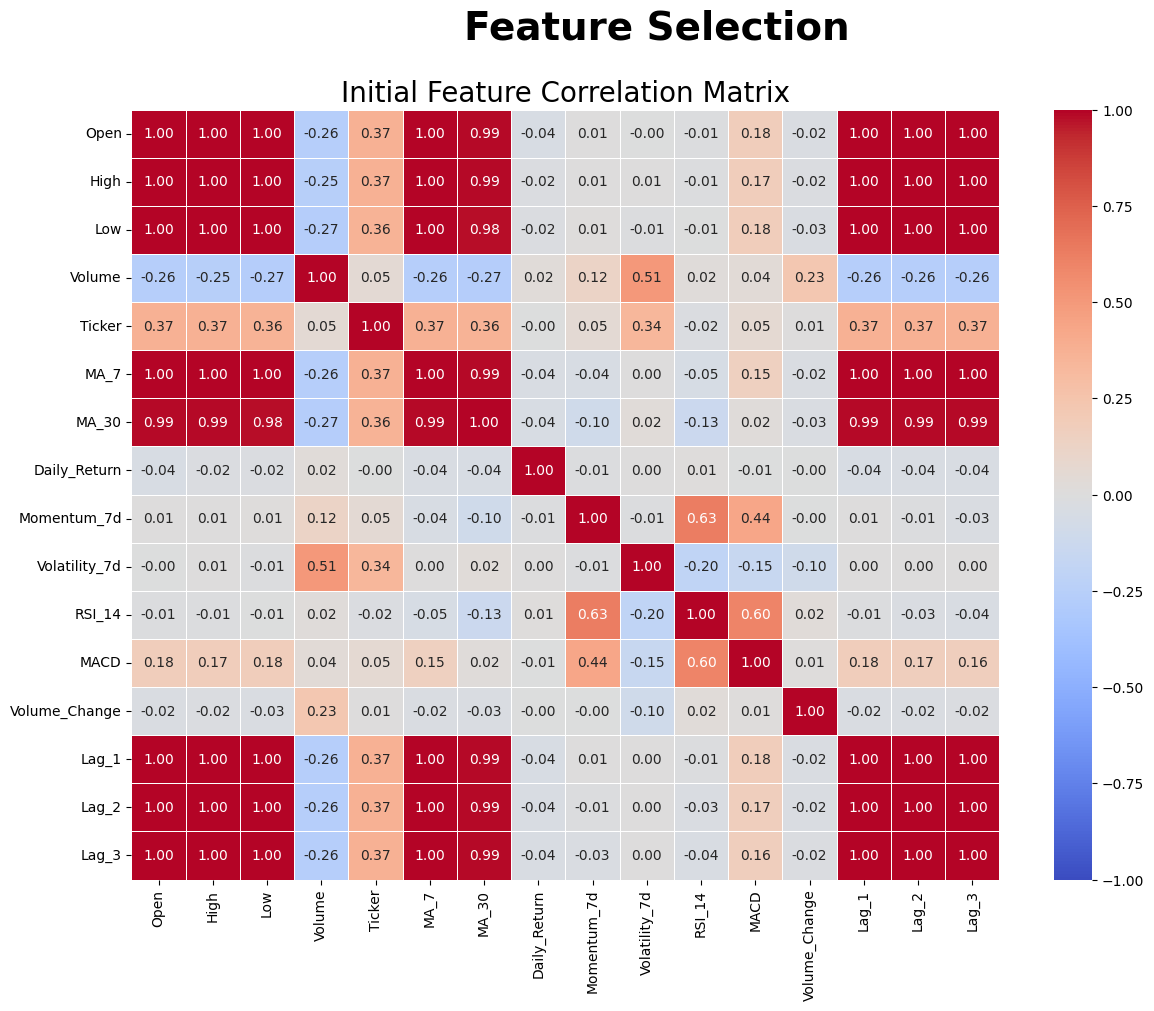

In [6]:
# Import libraries for correlation analysis
import seaborn as sbn
import matplotlib.pyplot as plt

# Feature Selection: Identify features that are highly correlated to each other.
feats_corr = feats_X.corr("pearson")

plt.figure(figsize=(14, 10))
sbn.heatmap(
    feats_corr,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.suptitle("Feature Selection", fontsize=28, fontweight="bold")
plt.title("Initial Feature Correlation Matrix", fontsize=20)
plt.show()


`Open`, `High`, `Low`, `MA_30`, and lagged price features are all strongly correlated with `MA_7` — they all represent price levels from recent days and carry near-identical information.

To reduce redundancy, we drop these and keep `MA_7` as the single price-level representative, since it provides a smoothed signal that is more stable and meaningful for stock prediction than raw or lagged prices.

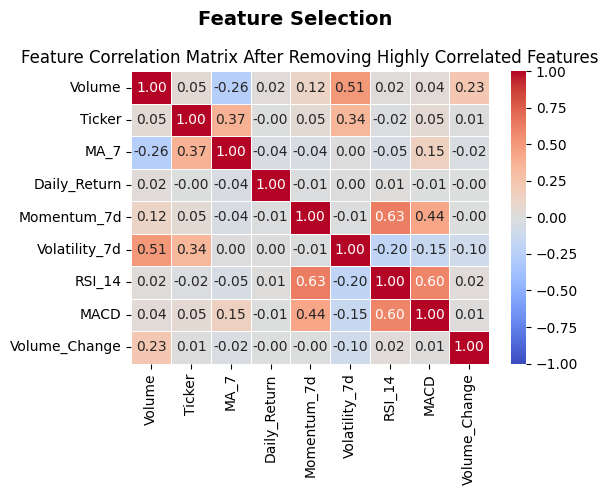

In [7]:
# Feature Selection: Remove highly correlated/redundant features.
useful_feats_X = feats_X.drop(columns=["Open", "High", "Low", "MA_30", "Lag_1", "Lag_2", "Lag_3"])

# Show updated matrix after reduction
useful_feats_corr = useful_feats_X.corr("pearson")

plt.figure(figsize=(6, 5))
sbn.heatmap(
    useful_feats_corr,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.suptitle("Feature Selection", fontsize=14, fontweight="bold")
plt.title("Feature Correlation Matrix After Removing Highly Correlated Features")
plt.tight_layout()
plt.show()


Our feature correlation matrix looks better after removing highly correlated and redundant features.

Although some features such as Momentum, Volatility, RSI, MACD, and Volume are moderately correlated, we keep them because they each capture a distinct aspect of market behavior:
- `Momentum_7d` measures speed of price change
- `Volatility` measures risk
- `RSI` measures overbought/oversold conditions
- `MACD` measures trend direction
- `Volume` measures trading activity. 

Removing any of them would lose relevant data for the regression model (predicting how much the price moves) and the classification model (predicting which direction it moves).

We can consider these selected features as our final feature set for model training.

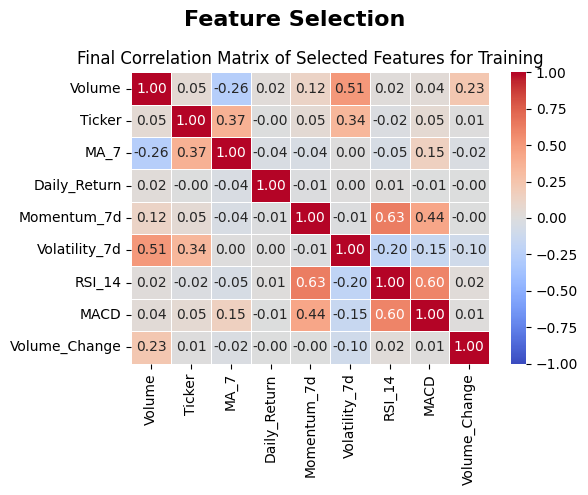

In [8]:
# Feature Selection: Final chosen features for training
useful_feats_corr = useful_feats_X.corr("pearson")

plt.figure(figsize=(6, 5))
sbn.heatmap(
    useful_feats_corr,
    annot=True,
    linewidths=0.5,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1
)
plt.suptitle("Feature Selection", fontsize=16, fontweight="bold")
plt.title("Final Correlation Matrix of Selected Features for Training")
plt.tight_layout()
plt.show()


#### Step 7: Graphical Data Preview
We will visualize the selected features for analysis.

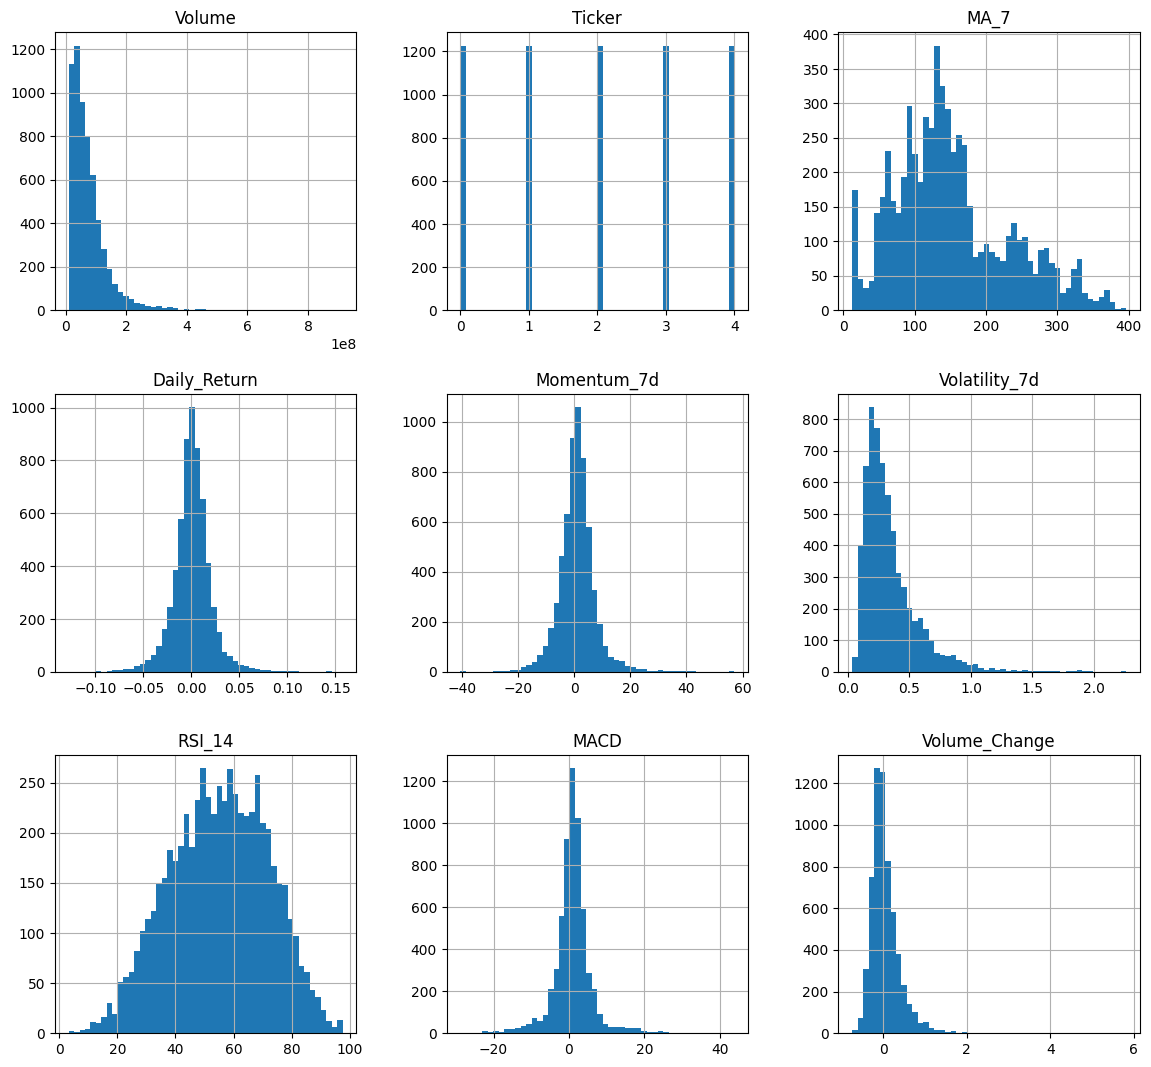

In [9]:
# Graphical Data Preview: visualize selected feature distributions
useful_feats_X.hist(bins=50, figsize=(14, 13))
plt.show()


#### Step 8: Train/Test Data Split, and Feature Normalization (<- Feature Engineering)
Split the data by ticker, then scale features.

The features live on very different scales — Volume is in the hundreds of millions, RSI is bounded 0–100, etc. We use `StandardScaler` to put every feature on the same scale (mean 0; std 1).

The scaler is **fit on training data only** and then applied to the test set. Fitting on the full dataset would leak future statistics into the training process.

In [10]:
# Import libraries
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Combine selected features, target outputs, and today's adjusted close for interpretation later
data = pd.concat([useful_feats_X, trgt_y, dataset[["Adj Close"]]], axis=1)

# Lists to store split data
train_list = []
test_list = []

# Perform chronological 80/20 split per ticker
for ticker in data["Ticker"].unique():
    ticker_df = data[data["Ticker"] == ticker].sort_index()

    # 80/20 split
    split_idx = int(len(ticker_df) * 0.8)

    train_list.append(ticker_df.iloc[:split_idx])
    test_list.append(ticker_df.iloc[split_idx:])

# Concatenate all ticker splits
train_df = pd.concat(train_list)
test_df = pd.concat(test_list)

# Define input features
feature_cols = list(useful_feats_X.columns)

# Scale features
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[feature_cols])
X_test = scaler.transform(test_df[feature_cols])

# Extract regression targets (price value)
y_train_reg = train_df["Target"]
y_test_reg = test_df["Target"]

# Extract classification targets (up/down indicator)
y_train_clf = train_df["Direction"]
y_test_clf = test_df["Direction"]


#### Step 9: Model Training/Validation/Testing
We will train two separate models:
1. A **classification model** to predict price direction
2. A **regression model** to predict future stock prices.

We use `XGBoost`, which builds decision trees sequentially so each new tree learns from the errors of previous trees. This helps capture complex patterns between technical indicators and stock movement.

Compared with common models such as Random Forest, XGBoost often achieves higher accuracy while Random Forest builds trees independently rather than improving past mistakes.

The selected hyperparameters balance learning and model complexity. These values were chosen through test validations predictive performance.

To validate the model, we use **walk-forward validation** with `TimeSeriesSplit`, where the model trains on older historical data and tests on newer unseen data for each fold. This method is more appropriate for stock prediction because it preserves time order.

##### Prepare the data for model validation

In [11]:
from xgboost import XGBClassifier, XGBRegressor
from sklearn.model_selection import TimeSeriesSplit

# 5 Fold counts
tscv = TimeSeriesSplit(n_splits=5)

# Combine all data for walk-forward validation (maintains chronological order)
X_all = np.vstack([X_train, X_test])          # All scaled features in order
y_all_reg = np.concatenate([y_train_reg, y_test_reg])   # All regression targets
y_all_clf = np.concatenate([y_train_clf, y_test_clf])   # All classification targets

##### Model 1: Classification Model
Train a XGBoost classifier to predict stock price direction (up or down) and evaluate its classification performance using accuracy, precision, recall, and F1-score.


In [12]:
# Fit and train main static classifier model
# Note: We manually tuned hyperparameters based on validation results
clf = XGBClassifier(
    subsample=0.8,
    n_estimators=300,
    learning_rate=0.01,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)
clf.fit(X_train, y_train_clf)
y_pred_clf = clf.predict(X_test)

# Store per-fold performance results
clf_wf_res = []

# Walk-Forward Validation
print("\nWalk-Forward Validation Classification Model Evaluation")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    
    # Fit scaler on training fold and transform it
    X_tr = scaler.fit_transform(X_all[train_idx])
    
    # Transform test fold using the already-fitted scaler
    X_te = scaler.transform(X_all[test_idx])

    # Fit/train validation classifier on the current training fold -> we hypertune these
    clf_wf = XGBClassifier(
        subsample=0.8,
        n_estimators=300,
        learning_rate=0.01,
        max_depth=4,
        random_state=42,
        eval_metric="logloss"
    )
    clf_wf.fit(X_tr, y_all_clf[train_idx])

    # Evaluate predictions on current fold
    acc = accuracy_score(y_all_clf[test_idx], clf_wf.predict(X_te))
    clf_wf_res.append({"fold": fold + 1, "accuracy": acc})          # Add to list for Model Evaluation section
    print(f"Fold {fold+1} | Accuracy: {acc:.4f}")                   # Print to verify



Walk-Forward Validation Classification Model Evaluation
Fold 1 | Accuracy: 0.5235
Fold 2 | Accuracy: 0.5196
Fold 3 | Accuracy: 0.5333
Fold 4 | Accuracy: 0.5147
Fold 5 | Accuracy: 0.5382


##### Model 2: Regression Model
Train a XGBoost regressor to predict future stock prices and evaluate prediction performance using MAE, RMSE, and R².


In [13]:
# Fit and train main static regression model
# Note: We manually tuned hyperparameters based on validation results
reg = XGBRegressor(
    subsample=0.8,
    n_estimators=300,
    max_depth=4,
    learning_rate=0.01,
    random_state=42
)
reg.fit(X_train, y_train_reg)
y_pred_reg = reg.predict(X_test)

# Store per-fold performance results
wf_reg_results = []

# Walk-Forward Validation
print("\nWalk-Forward Validation Regression Model Evaluation")
for fold, (train_idx, test_idx) in enumerate(tscv.split(X_all)):
    
    # Fit scaler on training fold and transform it
    X_tr = scaler.fit_transform(X_all[train_idx])
    
    # Transform test fold using the already-fitted scaler
    X_te = scaler.transform(X_all[test_idx])

    # Fit/train validation regressor on the current training fold -> we hypertune these
    reg_wf = XGBRegressor(
        subsample=0.8,
        n_estimators=300,
        max_depth=4,
        learning_rate=0.01,
        random_state=42
    )
    reg_wf.fit(X_tr, y_all_reg[train_idx])  
    y_pred_fold = reg_wf.predict(X_te)  # Generate predictions for current fold 

    # Evaluate predictions on current fold
    mae  = mean_absolute_error(y_all_reg[test_idx], y_pred_fold)            
    rmse = np.sqrt(mean_squared_error(y_all_reg[test_idx], y_pred_fold))       
    r2   = r2_score(y_all_reg[test_idx], y_pred_fold)                      

    wf_reg_results.append({"fold": fold + 1, "mae": mae, "rmse": rmse, "r2": r2}) 
    print(f"Fold {fold+1} | MAE: {mae:.4f} | RMSE: {rmse:.4f} | R2: {r2:.4f}")  




Walk-Forward Validation Regression Model Evaluation
Fold 1 | MAE: 2.9278 | RMSE: 4.1810 | R2: -0.0071
Fold 2 | MAE: 2.0383 | RMSE: 2.9674 | R2: -0.0663
Fold 3 | MAE: 1.2894 | RMSE: 1.8816 | R2: -0.0279
Fold 4 | MAE: 5.0546 | RMSE: 7.8796 | R2: -0.0222
Fold 5 | MAE: 3.1038 | RMSE: 4.5870 | R2: -0.0486


#### Step 10: Model Evaluation
We will measure how well the tuned trained models perform on unseen test data using evaluation metrics and visualizations.

##### Model Evaluation 1: Classification Model Evaluation
We will evaluate our classification model’s performance and visualize its predictions against the ground-truth labels.

In [14]:
print("Classification Model Evaluation")
print("Accuracy:", accuracy_score(y_test_clf, y_pred_clf))
print(classification_report(y_test_clf, y_pred_clf))


Classification Model Evaluation
Accuracy: 0.5260162601626016
              precision    recall  f1-score   support

           0       0.46      0.29      0.36       552
           1       0.55      0.72      0.62       678

    accuracy                           0.53      1230
   macro avg       0.51      0.50      0.49      1230
weighted avg       0.51      0.53      0.50      1230



**Classification Confusion Matrix** <br>
Visualize the classifier's predicted versus actual price direction to assess how well the model distinguishes between upward (price increase) and downward movements (price decrease).

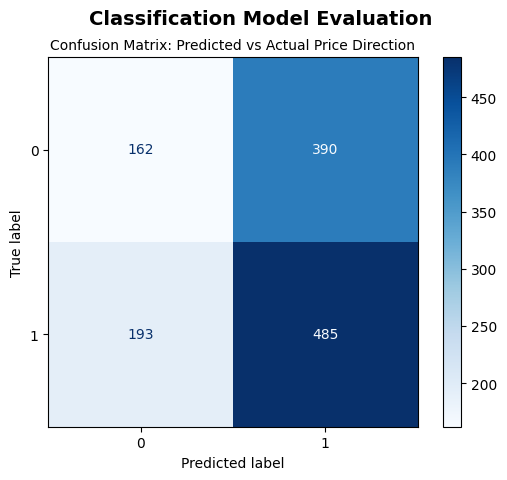

In [15]:
# Import tools for evaluating classification performance and visualization
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Compute confusion matrix comparing true vs predicted labels
cm = confusion_matrix(y_test_clf, y_pred_clf)

# Create display object for visualization
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

# Plot confusion matrix
disp.plot(cmap="Blues")
plt.suptitle("Classification Model Evaluation", fontsize=14, fontweight="bold")
plt.title("Confusion Matrix: Predicted vs Actual Price Direction", fontsize=10)
plt.show()


The confusion matrix is interpreted as follows:

| Actual / Predicted | Down | Up |
|---|---|---|
| **Down** | True Negative (Correct Down) | False Positive (Incorrect Up) |
| **Up** | False Negative (Incorrect Down) | True Positive (Correct Up) |


**Classification Feature Importance** <br>
Analyze which selected features contributed most to predicting stock price direction.

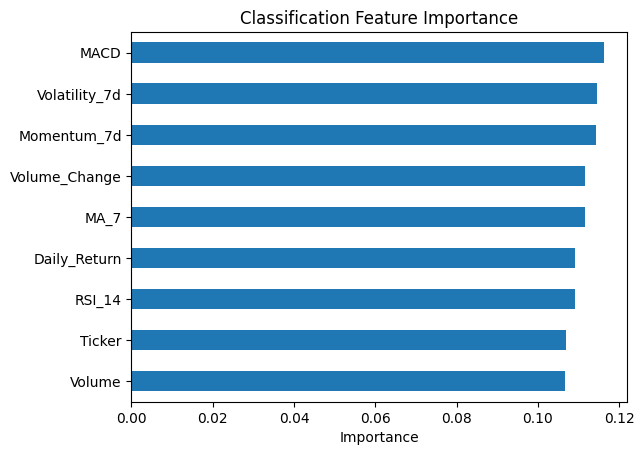

In [16]:
# Plot classification feature importances
importances_clf = pd.Series(clf.feature_importances_, index=feature_cols)
importances_clf.sort_values().plot(kind="barh")

plt.title("Classification Feature Importance")
plt.xlabel("Importance")
plt.show()


####

##### Model Evaluation 2: Regression Model Evaluation
Compare actual stock prices against predicted stock prices, and inspect prediction errors for patterns.

In [17]:
print("Regression Model Evaluation")
print("MAE:", mean_absolute_error(y_test_reg, y_pred_reg))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, y_pred_reg)))
print("R2:", r2_score(y_test_reg, y_pred_reg))

Regression Model Evaluation
MAE: 2.897541199698126
RMSE: 4.332891784662936
R2: -0.07446250073644523


**Regression Prediction Plot** <br>
Visualize the relationship between actual stock prices and predicted stock prices to assess prediction accuracy.

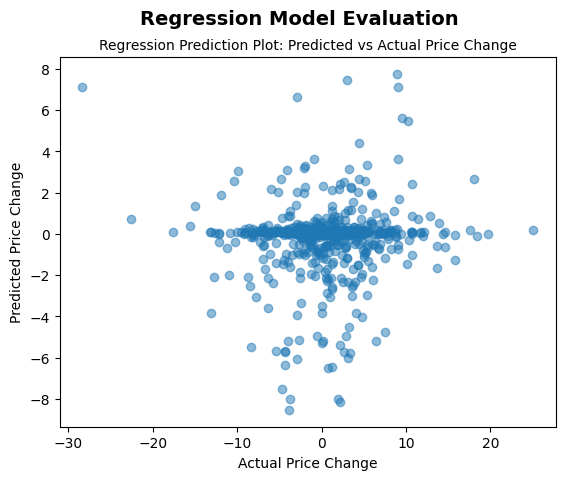

In [18]:
# Visualize relationship between actual and predicted values to assess regression performance
plt.scatter(y_test_reg, y_pred_reg, alpha=0.5)
plt.xlabel("Actual Price Change")
plt.ylabel("Predicted Price Change")
plt.title("Regression Prediction Plot: Predicted vs Actual Price Change", fontsize=10 )
plt.suptitle("Regression Model Evaluation", fontsize=14, fontweight="bold")
plt.show()


**Regression Residual Plot** <br>
Visualize prediction errors (residuals) to identify bias, outliers, or systematic error patterns.

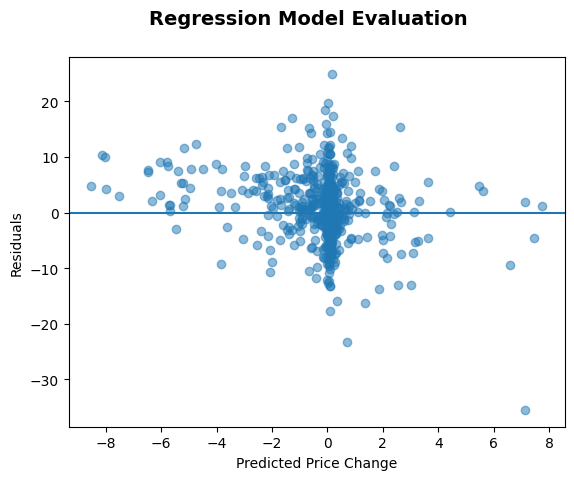

In [19]:
# Plot residuals to evaluate prediction errors and check for patterns in model performance
residuals = y_test_reg - y_pred_reg

plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.xlabel("Predicted Price Change")
plt.ylabel("Residuals")
plt.suptitle("Regression Model Evaluation", fontsize=14, fontweight="bold")
plt.axhline(0)
plt.show()


**Regression Feature Importance** <br>
Analyze which selected features contributed most to future stock price predictions.

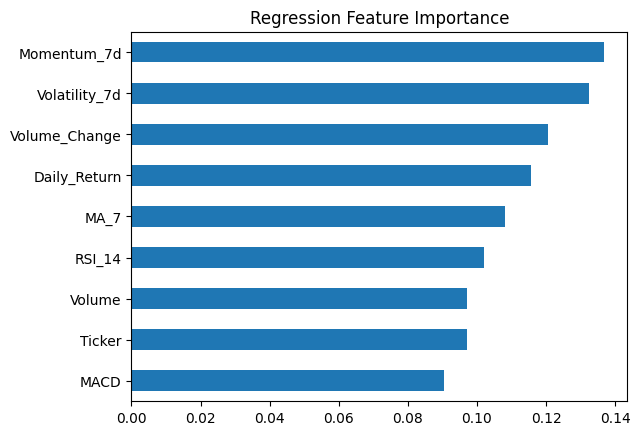

In [20]:
# Plot feature importance to identify which features contribute most to the regression model
importances_reg = pd.Series(reg.feature_importances_, index=feature_cols)
importances_reg.sort_values().plot(kind="barh")

plt.title("Regression Feature Importance")
plt.show()


In [21]:
# Verify dataset split and class distribution again to ensure no imbalance or data issues
print("Train size:", len(X_train))
print("Test size:", len(X_test))

print("\nDirection distribution (test):")
print(y_test_clf.value_counts())


Train size: 4905
Test size: 1230

Direction distribution (test):
Direction
1    678
0    552
Name: count, dtype: int64


#### Step 11: Model Prediction and Interpretation
Combine regression and classification predictions into readable final results.

In [22]:
# Extract the current row's adjusted close price from the test set for comparison with next-day predictions.
today_price = test_df["Adj Close"].values

# Combine regression and classification outputs into a single result set for interpretation
results = pd.DataFrame({
    "Date": test_df.index,                                  # Current row date (treated as today); predictions are for the next trading day
    "Ticker": ordEnc.inverse_transform(test_df[["Ticker"]].values).flatten(),       # Ticker Group
    "Todays Price": today_price,                            # Today's price
    "Predicted Price": today_price + y_pred_reg,            # Next-day price prediction (regression)
    "Actual Price": today_price + y_test_reg.values,        # Next-day actual price 
    "Classifier Direction": y_pred_clf                      # Next-day price direction (classification)
})

# Convert direction values into readable labels
results["Price Direction"] = results["Classifier Direction"].map({1: "Up", 0: "Down"})

# Format date for readability
results["Date"] = pd.to_datetime(results["Date"]).dt.strftime("%Y-%m-%d")

# Add columns showing whether each model prediction was correct (for inspection and performance analysis)

# Calculate percentage error (how off the prediction was)
results["Pct Error"] = (abs(results["Predicted Price"] - results["Actual Price"]) / results["Actual Price"]) * 100

# Use the model's average percentage error as the threshold for acceptable forecasts
thresh = round(results["Pct Error"].mean(), 6)
results[f"Within {thresh}% of Actual"] = np.where(
    results["Pct Error"] <= thresh, "Yes", "No"
)

# Classification correct if predicted direction matches actual direction
results["Classification Prediction Correct?"] = np.where(
    results["Classifier Direction"] == y_test_clf.values, "Yes", "No"
)

# Display first 5 rows from each ticker
results.groupby("Ticker").head(2).drop(columns=["Classifier Direction"])


,Date,Ticker,Todays Price,Predicted Price,Actual Price,Price Direction,Pct Error,Within 1.534451% of Actual,Classification Prediction Correct?
0,2023-01-06,AAPL,128.560867,128.498537,129.086548,Down,0.455517,Yes,No
1,2023-01-09,AAPL,129.086548,129.166965,129.661789,Up,0.381626,Yes,Yes
246,2023-01-06,MSFT,222.140869,222.542699,224.303726,Up,0.785108,Yes,Yes
247,2023-01-09,MSFT,224.303726,224.361065,226.012253,Down,0.730575,Yes,No
492,2023-01-06,AMZN,86.080002,85.991963,87.360001,Down,1.565977,No,No
493,2023-01-09,AMZN,87.360001,87.453035,89.870003,Up,2.689404,No,Yes
738,2023-01-06,GOOGL,87.239868,87.284317,87.919090,Up,0.721997,Yes,Yes
739,2023-01-09,GOOGL,87.919090,88.017319,88.318634,Up,0.341168,Yes,Yes
984,2023-01-06,TSLA,113.059998,112.364387,119.769997,Down,6.183193,No,No
985,2023-01-09,TSLA,119.769997,119.707921,118.849998,Down,0.721853,Yes,Yes


In [23]:
# Summary table of model performance
summary = results.groupby("Ticker").agg(
    Total_Predictions=("Ticker", "count"),
    Regression_Correct=(f"Within {thresh}% of Actual", lambda x: (x == "Yes").sum()),
    Classification_Correct=("Classification Prediction Correct?", lambda x: (x == "Yes").sum())
)

# Add accuracy percentages
summary["Regression Accuracy %"] = (
    summary["Regression_Correct"] / summary["Total_Predictions"] * 100
).round(2)

summary["Classification Accuracy %"] = (
    summary["Classification_Correct"] / summary["Total_Predictions"] * 100
).round(2)

summary


,Total_Predictions,Regression_Correct,Classification_Correct,Regression Accuracy %,Classification Accuracy %
Ticker,,,,,
AAPL,246,200,129,81.30,52.44
AMZN,246,140,134,56.91,54.47
GOOGL,246,165,128,67.07,52.03
MSFT,246,159,118,64.63,47.97
TSLA,246,106,138,43.09,56.10


In [24]:
# Add combined average accuracy across all tickers
print("Average % Regression Accuracy Across All Tickers:", round(summary["Regression Accuracy %"].mean(), 2))
print("Average % Classification Accuracy Across All Tickers:", round(summary["Classification Accuracy %"].mean(), 2))

Average % Regression Accuracy Across All Tickers: 62.6
Average % Classification Accuracy Across All Tickers: 52.6


##### Final Results Discussion

The AI model shows moderate predictive ability with 62.27% regression accuracy and 52.60% classification accuracy for next-day direction. A key limitation is that one shared model with the same hyperparameters was used across all five tickers, even though each stock has different volatility, momentum patterns, and market drivers. As a result, the model captures useful historical trends but cannot fully optimize for every ticker.